### Notebook seguimiento `00_auditoria_general.md`

CELDA 1

In [20]:
import subprocess

cmd = [
    r"C:\TSIS_Data\v1\backtest_SmallCaps\backtest\Scripts\python.exe",
    r"C:\TSIS_Data\v1\backtest_SmallCaps\scripts\agent_universe_audit.py",
    "--outdir",
    r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare",
]

res = subprocess.run(cmd, capture_output=True, text=True, check=True)
print(res.stdout)
if res.stderr:
    print(res.stderr)

universe-audit
outdir : C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare
----------------------------------------------------------------------------------------------------
overall: OK
mode   : final-audit
panel  : rows=31294565 snapshots=8034 max_snapshot=2026-12-31
qa     : final_rows=8034 final_max=2026-12-31 partial_rows=None partial_max=None
ckpt   : count=8034 max_snapshot=2026-12-31

checks:
- [OK] required_outputs: Artefactos base presentes.
- [OK] entity_integrity: Sin duplicados ni nulos en entity_id.
- [OK] meta_vs_panel: Meta consistente con panel final.
- [OK] qa_vs_panel: QA final consistente con snapshots del panel.
- [OK] progress_status: Corrida marcada como completed.
- [OK] progress_freshness: progress fresco: age_min=11062.8.

accion_recomendada:
1) Puedes usar estos artefactos como base para Agent01/Agent05.



CELDA 2

In [2]:
from pathlib import Path
import json
import pandas as pd
import pyarrow.dataset as ds

OUTDIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare")

PANEL_DIR = OUTDIR / "tickers_panel_pti"
ALL_FP = OUTDIR / "tickers_all.parquet"
ACTIVE_FP = OUTDIR / "tickers_active.parquet"
INACTIVE_FP = OUTDIR / "tickers_inactive.parquet"
QA_FP = OUTDIR / "qa_coverage_by_cut.csv"
META_FP = OUTDIR / "build_universe_pti.meta.json"

print("=== EXISTENCIA ===")
for p in [PANEL_DIR, ALL_FP, ACTIVE_FP, INACTIVE_FP, QA_FP, META_FP]:
    print(f"{p}: {'OK' if p.exists() else 'MISSING'}")

print("\n=== META ===")
if META_FP.exists():
    meta = json.loads(META_FP.read_text(encoding="utf-8"))
    print(json.dumps(meta, indent=2, ensure_ascii=False))
else:
    meta = None
    print("META no existe")

print("\n=== PANEL DATASET ===")
if PANEL_DIR.exists():
    panel_ds = ds.dataset(str(PANEL_DIR), format="parquet")
    panel_rows = panel_ds.count_rows()
    snap_tbl = panel_ds.to_table(columns=["snapshot_date"])
    snap_s = pd.Series(snap_tbl.column("snapshot_date").to_pylist()).dropna().astype(str).str[:10]
    print(f"panel_rows: {panel_rows:,}")
    print(f"snapshots_n: {snap_s.nunique():,}")
    print(f"snapshot_min: {snap_s.min()}")
    print(f"snapshot_max: {snap_s.max()}")
else:
    print("PANEL no existe")

print("\n=== TICKERS_ALL ===")
if ALL_FP.exists():
    d_all = pd.read_parquet(ALL_FP)
    print(f"rows: {len(d_all):,}")
    print(f"unique_entity_id: {d_all['entity_id'].nunique():,}" if "entity_id" in d_all.columns else "entity_id: columna noencontrada")
    if "status" in d_all.columns:
        print("status_counts:")
        print(d_all["status"].value_counts(dropna=False).to_string())
    if "status_confidence" in d_all.columns:
        print("status_confidence_counts:")
        print(d_all["status_confidence"].value_counts(dropna=False).to_string())
    print("\ncolumns:")
    print(list(d_all.columns))
else:
    print("tickers_all.parquet no existe")

print("\n=== ACTIVE / INACTIVE ===")
if ACTIVE_FP.exists():
    d_active = pd.read_parquet(ACTIVE_FP)
    print(f"active_rows: {len(d_active):,}")
else:
    print("tickers_active.parquet no existe")

if INACTIVE_FP.exists():
    d_inactive = pd.read_parquet(INACTIVE_FP)
    print(f"inactive_rows: {len(d_inactive):,}")
else:
    print("tickers_inactive.parquet no existe")

print("\n=== QA COVERAGE ===")
if QA_FP.exists():
    d_qa = pd.read_csv(QA_FP)
    print(f"qa_rows: {len(d_qa):,}")
    if "snapshot_date" in d_qa.columns:
        print(f"qa_snapshot_min: {d_qa['snapshot_date'].min()}")
        print(f"qa_snapshot_max: {d_qa['snapshot_date'].max()}")
    print("\nqa_head:")
    display(d_qa.head())
    print("\nqa_tail:")
    display(d_qa.tail())
else:
    print("qa_coverage_by_cut.csv no existe")

=== EXISTENCIA ===
C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare\tickers_panel_pti: OK
C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare\tickers_all.parquet: OK
C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare\tickers_active.parquet: OK
C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare\tickers_inactive.parquet: OK
C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare\qa_coverage_by_cut.csv: OK
C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare\build_universe_pti.meta.json: OK

=== META ===
{
  "start": "2005-01-01",
  "end": "2026-12-31",
  "outdir": "C:\\TSIS_Data\\v1\\backtest_SmallCaps\\data\\reference\\universe_pti_rebuild_compare",
  "panel_rows": 31294565,
  "existing_panel_rows_before_append": 0,
  "existing_qa_rows_before_append": 0,
  "entities": 16010,
  "active": 5267,
  "inactive": 10743,
  "last_snapsh

,snapshot_date,rows_raw,rows_dedup,entities,dupes_by_snapshot_entity,null_entity_id,null_composite_figi,null_share_class_figi
0,2005-01-01,2632,2632,2632,0,0,1599,1599
1,2005-01-02,2632,2632,2632,0,0,1599,1599
2,2005-01-03,2630,2630,2630,0,0,1597,1597
3,2005-01-04,2630,2630,2630,0,0,1597,1597
4,2005-01-05,2631,2630,2630,1,0,1597,1597



qa_tail:


,snapshot_date,rows_raw,rows_dedup,entities,dupes_by_snapshot_entity,null_entity_id,null_composite_figi,null_share_class_figi
8029,2026-12-27,5267,5267,5267,0,0,1063,1064
8030,2026-12-28,5267,5267,5267,0,0,1063,1064
8031,2026-12-29,5267,5267,5267,0,0,1063,1064
8032,2026-12-30,5267,5267,5267,0,0,1063,1064
8033,2026-12-31,5267,5267,5267,0,0,1063,1064


CELDA 3

In [24]:
import pandas as pd

input_path = r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare\tickers_2005_2026.parquet"
df_input = pd.read_parquet(input_path)

print("\nOUTPUT")
print("shape:", df_input.shape)
print("rows_total:", len(df_input))
print("columns:", list(df_input.columns))

print("output_ticker_unique:", df_input["ticker"].astype(str).str.strip().str.upper().nunique())


OUTPUT
shape: (16010, 26)
rows_total: 16010
columns: ['ticker', 'name', 'market', 'locale', 'primary_exchange', 'type', 'active', 'currency_name', 'cik', 'composite_figi', 'share_class_figi', 'list_date', 'delisted_utc', 'last_updated_utc', 'snapshot_date', 'entity_id', 'exchange_priority', 'has_composite_figi', 'has_share_class_figi', 'has_list_date', 'cut_frequency', 'first_seen_date', 'last_seen_date', 'latest_active', 'status_confidence', 'status']
output_ticker_unique: 12491


CELDA 4

In [25]:
import pandas as pd


output_path = r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper.parquet"
df_out = pd.read_parquet(output_path)

print("\nOUTPUT")
print("shape:", df_out.shape)
print("rows_total:", len(df_out))
print("columns:", list(df_out.columns))

print("output_ticker_unique:", df_out["ticker"].astype(str).str.strip().str.upper().nunique())


OUTPUT
shape: (12468, 26)
rows_total: 12468
columns: ['ticker', 'name', 'market', 'locale', 'primary_exchange', 'type', 'active', 'currency_name', 'cik', 'composite_figi', 'share_class_figi', 'list_date', 'delisted_utc', 'last_updated_utc', 'snapshot_date', 'entity_id', 'exchange_priority', 'has_composite_figi', 'has_share_class_figi', 'has_list_date', 'cut_frequency', 'first_seen_date', 'last_seen_date', 'latest_active', 'status_confidence', 'status']
output_ticker_unique: 12468


## Descarga `market_cap_cutoff_lt_1b_active_inactive.parquet`

In [8]:
import polars as pl

path = r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\market_cap_last_observed_cutoff\20260320_market_cap_last_observed_cutoff\market_cap_cutoff_lt_1b_active_inactive.parquet"

df = pl.read_parquet(path)
print(df.head(1).to_pandas().T)

                                                        0
ticker                                               AACT
first_seen_date                       2023-06-12 00:00:00
last_observed_date                    2025-09-24 00:00:00
status_rebuilt                                   inactive
last_row_date                         2025-09-24 00:00:00
anchor_date_used                      2025-09-24 00:00:00
close_t                                              9.49
shares_outstanding_t                           55470890.5
shares_source                                     diluted
shares_observed_date                  2025-08-12 00:00:00
shares_period_end                     2024-06-30 00:00:00
shares_age_days                                      43.0
market_cap_t                                526418750.845
is_small_cap_t                                       True
classification_1b                     inactive_died_lt_1b
classification_reason_1b  inactive_and_market_cap_t_lt_1b


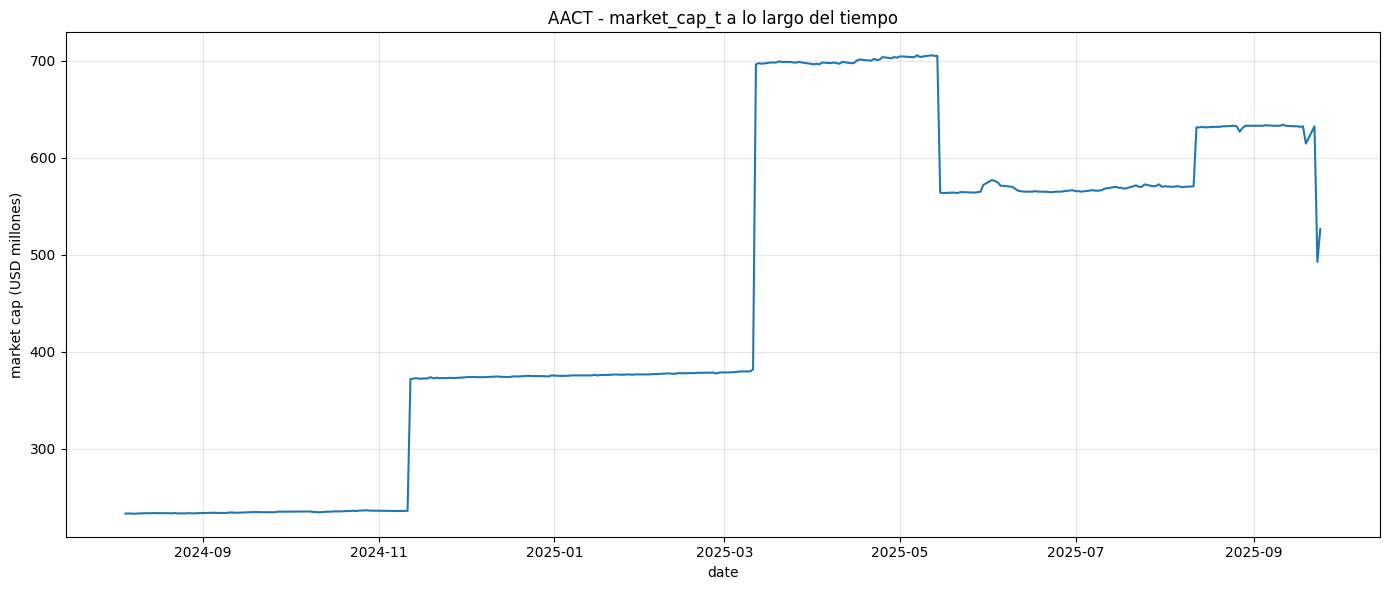

In [18]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

PTI_PATH = r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01\population_target_pti.parquet"
TICKER = "AACT"

df = (
    pl.scan_parquet(PTI_PATH)
    .filter(pl.col("ticker") == TICKER)
    .select(["date", "market_cap_t"])
    .sort("date")
    .collect()
    .filter(pl.col("market_cap_t").is_not_null())
)

pdf = df.to_pandas()
pdf["date"] = pd.to_datetime(pdf["date"])
pdf["market_cap_m"] = pdf["market_cap_t"] / 1_000_000

plt.figure(figsize=(14, 6))
plt.plot(pdf["date"], pdf["market_cap_m"], linewidth=1.5)
plt.title(f"{TICKER} - market_cap_t a lo largo del tiempo")
plt.xlabel("date")
plt.ylabel("market cap (USD millones)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
from pathlib import Path

fp = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\universe_coverage_lt_1b\20260322_lt_1b_quotes_trades_cross\quotes_missing.csv")
df = pd.read_csv(fp)

print(f"path: {fp}")
print(f"shape: {df.shape}")
print(df.head(5))

path: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\universe_coverage_lt_1b\20260322_lt_1b_quotes_trades_cross\quotes_missing.csv
shape: (3477, 1)
  ticker
0   AACT
1   AAGR
2   AAIC
3   AAMC
4   AAME


In [3]:
import pandas as pd
from pathlib import Path

fp = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\market_cap_last_observed_cutoff\20260320_market_cap_last_observed_cutoff\market_cap_cutoff_lt_1b_active_inactive.parquet")
df = pd.read_parquet(fp)

print(f"path: {fp}")
print(f"shape: {df.shape}")
print(df.head(1).T)

path: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\market_cap_last_observed_cutoff\20260320_market_cap_last_observed_cutoff\market_cap_cutoff_lt_1b_active_inactive.parquet
shape: (4824, 16)
                                                        0
ticker                                               AACT
first_seen_date                       2023-06-12 00:00:00
last_observed_date                    2025-09-24 00:00:00
status_rebuilt                                   inactive
last_row_date                         2025-09-24 00:00:00
anchor_date_used                      2025-09-24 00:00:00
close_t                                              9.49
shares_outstanding_t                           55470890.5
shares_source                                     diluted
shares_observed_date                  2025-08-12 00:00:00
shares_period_end                     2024-06-30 00:00:00
shares_age_days                                      43.0
market_cap_t                                52641875

He creado:

- C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/cell_code/cross_lt_1b_vs_ohlcv_daily_windows.py
- C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/cell_code/run_cross_lt_1b_vs_ohlcv_daily_windows.ps1

Lanzadera:

powershell -NoProfile -ExecutionPolicy Bypass -File C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\run_cross_lt_1b_vs_ohlcv_daily_windows.ps1

Prueba corta:

powershell -NoProfile -ExecutionPolicy Bypass -File C:
\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\run_cross_lt_1b_vs_ohlcv_daily_windows.ps1 -LimitTickers 100

  Qué saca:

  - lt_1b_vs_ohlcv_daily_windows.parquet
  - lt_1b_vs_ohlcv_daily_windows.csv
  - window_differs.csv
  - no_ohlcv_daily.csv
  - summary.json

  Y añade por ticker:

  - has_ohlcv_daily
  - ohlcv_first_day
  - ohlcv_last_day
  - ohlcv_span_days
  - delta_first_vs_first_seen_days
  - delta_last_vs_last_observed_days
  - window_compare_status

In [9]:
import pandas as pd
from pathlib import Path

fp = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\lt_1b_vs_ohlcv_daily_windows\20260322_202042_cross_lt_1b_vs_ohlcv_daily_windows\lt_1b_vs_ohlcv_daily_windows.parquet")
df = pd.read_parquet(fp)

print(f"path: {fp}")
print(f"shape: {df.shape}")
print(df.head(2).T)

path: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\lt_1b_vs_ohlcv_daily_windows\20260322_202042_cross_lt_1b_vs_ohlcv_daily_windows\lt_1b_vs_ohlcv_daily_windows.parquet
shape: (4824, 26)
                                                                0  \
ticker                                                       AACT   
first_seen_date                               2023-06-12 00:00:00   
last_observed_date                            2025-09-24 00:00:00   
status_rebuilt                                           inactive   
last_row_date                                 2025-09-24 00:00:00   
anchor_date_used                              2025-09-24 00:00:00   
close_t                                                      9.49   
shares_outstanding_t                                   55470890.5   
shares_source                                             diluted   
shares_observed_date                          2025-08-12 00:00:00   
shares_period_end                             2024-

In [11]:

import pandas as pd
from pathlib import Path

fp = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\lt_1b_vs_ohlcv_daily_windows\20260322_202042_cross_lt_1b_vs_ohlcv_daily_windows\lt_1b_vs_ohlcv_daily_windows.parquet")
df = pd.read_parquet(fp)

diff = df[df["window_compare_status"] == "WINDOW_DIFFERS"].copy()

diff["abs_delta_first_days"] = diff["delta_first_vs_first_seen_days"].abs()
diff["abs_delta_last_days"] = diff["delta_last_vs_last_observed_days"].abs()
diff["abs_delta_total_days"] = diff["abs_delta_first_days"].fillna(0) + diff["abs_delta_last_days"].fillna(0)

cols = [
    "ticker",
    "first_seen_date",
    "last_observed_date",
    "ohlcv_first_day",
    "ohlcv_last_day",
    "delta_first_vs_first_seen_days",
    "delta_last_vs_last_observed_days",
    "status_rebuilt",
    "classification_1b",
    "window_compare_status",
]

diff = diff.sort_values(
    ["abs_delta_total_days", "abs_delta_last_days", "abs_delta_first_days", "ticker"],
    ascending=[False, False, False, True],
)

print(f"window_differs_rows: {len(diff)}")
display(diff[cols].head(5))

window_differs_rows: 4424


,ticker,first_seen_date,last_observed_date,ohlcv_first_day,ohlcv_last_day,delta_first_vs_first_seen_days,delta_last_vs_last_observed_days,status_rebuilt,classification_1b,window_compare_status
66,ADAM,2025-09-03,2026-03-09,2005-01-03,2026-03-06,-7548,-3,active,active_lt_1b_last_classifiable,WINDOW_DIFFERS
1235,DKI,2025-08-08,2026-03-09,2005-01-03,2026-03-06,-7522,-3,active,active_lt_1b_last_classifiable,WINDOW_DIFFERS
4152,SUPX,2025-06-02,2026-03-09,2005-01-03,2026-03-06,-7455,-3,active,active_lt_1b_last_classifiable,WINDOW_DIFFERS
4042,SPEC,2023-10-20,2024-08-06,2005-01-03,2026-03-05,-6864,576,inactive,inactive_died_lt_1b,WINDOW_DIFFERS
145,AII,2025-05-07,2026-03-09,2005-01-03,2026-03-06,-7429,-3,active,active_lt_1b_last_classifiable,WINDOW_DIFFERS


In [13]:
import pandas as pd
from pathlib import Path

fp = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_lt_1b_tasks\20260322_221029_build_quotes_lt_1b_master_from_ohlcv_windows\tasks_quotes_lt_1b_master.csv")
df = pd.read_csv(fp)

print(f"path: {fp}")
print(f"shape: {df.shape}")
print(df.head(10))

path: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_lt_1b_tasks\20260322_221029_build_quotes_lt_1b_master_from_ohlcv_windows\tasks_quotes_lt_1b_master.csv
shape: (11391979, 2)
  ticker        date
0   AACT  2023-06-12
1   AACT  2023-06-13
2   AACT  2023-06-14
3   AACT  2023-06-15
4   AACT  2023-06-16
5   AACT  2023-06-19
6   AACT  2023-06-20
7   AACT  2023-06-21
8   AACT  2023-06-22
9   AACT  2023-06-23


In [14]:
import pandas as pd
from pathlib import Path

src = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_lt_1b_missing_only\20260322_221951_build_quotes_lt_1b_missing_only_from_disk\tasks_quotes_lt_1b_missing_only.csv")
out = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_lt_1b_missing_only\20260322_221951_build_quotes_lt_1b_missing_only_from_disk\tasks_quotes_lt_1b_missing_only_smoke_5000.csv")

df = pd.read_csv(src)
smoke = df.head(5000).copy()
smoke.to_csv(out, index=False)

print(out)
print(smoke.shape)
display(smoke.head(10))

C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_lt_1b_missing_only\20260322_221951_build_quotes_lt_1b_missing_only_from_disk\tasks_quotes_lt_1b_missing_only_smoke_5000.csv
(5000, 2)


,ticker,date
0,AACT,2023-06-12
1,AACT,2023-06-13
2,AACT,2023-06-14
3,AACT,2023-06-15
4,AACT,2023-06-16
5,AACT,2023-06-19
6,AACT,2023-06-20
7,AACT,2023-06-21
8,AACT,2023-06-22
9,AACT,2023-06-23


In [19]:
# trade triks
import pandas as pd
from pathlib import Path

fp = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_lt_1b_tasks\20260324_200919_build_trades_lt_1b_master_from_ohlcv_windows\tasks_trades_lt_1b_master.csv")
df = pd.read_csv(fp)

print(f"path: {fp}")
print(f"shape: {df.shape}")
print(df.head(10))

path: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_lt_1b_tasks\20260324_200919_build_trades_lt_1b_master_from_ohlcv_windows\tasks_trades_lt_1b_master.csv
shape: (11391979, 2)
  ticker        date
0   AACT  2023-06-12
1   AACT  2023-06-13
2   AACT  2023-06-14
3   AACT  2023-06-15
4   AACT  2023-06-16
5   AACT  2023-06-19
6   AACT  2023-06-20
7   AACT  2023-06-21
8   AACT  2023-06-22
9   AACT  2023-06-23


In [22]:
import pandas as pd

path = r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_lt_1b_remaining_after_d_stop\20260327_165624_build_quotes_lt_1b_remaining_after_d_stop\tasks_quotes_lt_1b_remaining_after_d_stop.csv"

df = pd.read_csv(path)

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df.sort_values(["date", "current_status"], na_position="last")

summary = (
    df.groupby("current_status", dropna=False)
    .agg(
        rows=("current_status", "size"),
        min_date=("date", "min"),
        max_date=("date", "max"),
    )
    .sort_values(["min_date", "rows"], ascending=[True, False])
)

summary


C:\Users\AlexJ\AppData\Local\Temp\ipykernel_32856\285592896.py:5: DtypeWarning: Columns (0: current_status) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,rows,min_date,max_date
current_status,,,
NaN,2168108,2005-01-03,2026-03-06
DOWNLOAD_PARTIAL,3,2017-01-11,2021-02-18
DOWNLOAD_FAIL,2,2020-09-15,2021-12-08


In [7]:
import pandas as pd

path = r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_lt_1b_tasks\20260322_221029_build_quotes_lt_1b_master_from_ohlcv_windows\tasks_quotes_lt_1b_master.csv"

df = pd.read_csv(path)

print("rows_total:", len(df))

print(df.sort_values(df.columns.tolist(), ascending=False).tail(10))

rows_total: 11391979
        ticker        date
6920915    NaN  2022-07-25
6920914    NaN  2022-07-22
6920913    NaN  2022-07-21
6920912    NaN  2022-07-20
6920911    NaN  2022-07-19
6920910    NaN  2022-07-18
6920909    NaN  2022-07-15
6920908    NaN  2022-07-14
6920907    NaN  2022-07-13
6920906    NaN  2022-07-12


In [5]:
import pandas as pd

path = r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_lt_1b_tasks\20260322_221029_build_quotes_lt_1b_master_from_ohlcv_windows\tasks_quotes_lt_1b_master.csv"

df = pd.read_csv(path)

nan_by_column = df.isna().sum().sort_values(ascending=False)
nan_total = int(df.isna().sum().sum())

print("nan_total:", nan_total)
print("\nnan_by_column:")
nan_by_column

nan_total: 954

nan_by_column:


ticker    954
date        0
dtype: int64

In [8]:
tickers_unique = df["ticker"].astype(str).str.strip().str.upper().nunique()
print("tickers_unique:", tickers_unique)

tickers_unique: 4823


## ohlcv_daily

Universo usado

- `tickers_2005_2026_upper.parquet`

Pruebas

- `agent_06_validate_ohlcv_daily_realtime.ipynb`
    - referencia explícita a *tickers_2005_2026_upper.parquet*
- `044_agent_validate_ohlcv_daily_strict.py`
    - *EXPECTED_TICKERS_PARQUET = ...tickers_2005_2026_upper.parquet*
- Script de descarga:
    - *download_ohlcv_daily_v1.py*
    - deja auditoría en *download_ohlcv_daily_v1.ticker_audit.csv*

In [10]:
# ohlcv_daily



## ohlcv_1m

Universo base usado

- también arranca desde `tickers_2005_2026_upper.parquet`

Pruebas

- `audit_ohlcv_1m_hours.py`
    - referencia explícita a tickers_2005_2026_upper.parquet
- `audit_ohlcv_input_vs_daily_vs_1m.py`
    - compara upper.parquet contra D:\ohlcv_daily y D:\ohlcv_1m
- `build_missing_ohlcv_1m_input.py`
    - genera:
        - *tickers_missing_in_ohlcv_1m_vs_daily.parquet*
        - *tickers_missing_in_ohlcv_1m_vs_daily.csv*
- Script de validación:
    - *045_agent_validate_ohlcv_1m_strict.py*

Lectura

- ohlcv_1m usa el universo amplio upper.parquet, y luego tiene un subuniverso derivado para faltantes respecto a
daily.

## quotes

```sh
 python C:\TSIS_Data\v1\backtest_SmallCaps\scripts\download_quotes.py 
    --csv C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean\inputs\tasks_quotes_prod_missing_only_final_v2.csv 
    --output D:\quotes 
    --concurrent 24 
    --run-id 20260313_quotes_prod_full_12133_clean 
    --run-dir C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean 
    --resume 
    --task-batch-size 500 run_id=20260313_quotes_prod_full_12133_clean
```

**tasks_quotes_prod_missing_only_final_v2.csv**  sale de la fase de recovery/reconciliación del run viejo.

## Hilo correcto

  1. Se parte de:

  - tasks_quotes_prod.csv

  2. Luego se compara contra:

  - estado de descarga
  - disco real
  - reparaciones desde history

  3. De ahí se construye un subconjunto “faltantes”:

  - tasks_quotes_prod_missing_only_final.csv
  - y después
  - tasks_quotes_prod_missing_only_final_v2.csv

  ## Quién lo crea conceptualmente

  Lo crea un Recovery Builder manual/de facto, no un agente limpio de producción.

  Por eso en los notebooks v2 lo estábamos separando como una capa propia:

  - recovery builder
  - distinta de universe builder
  - distinta de Agent01

  El hilo es este:

  ## 1. Fuente upstream de tickers

  - tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.parquet

  ## 2. Se cruza con lifecycle oficial

  - official_lifecycle_compiled.csv

  La lógica observada fue:

  u = parquet_refinado
  lc = official_lifecycle
  base = lc[lc["ticker"].isin(set(u["ticker"]))]
  base = base.drop_duplicates(subset=["ticker"])

  ## 3. De ahí sale

  - tickers_quotes_prod.csv

  ## 4. Luego ese base se expande a días

  En el flujo viejo, se hizo algo como:

  days = pd.bdate_range(list_date, end_date)

  para cada ticker del base.

  Y de esa expansión sale:

  - tasks_quotes_prod.csv

  ## Dónde está documentado

  Está reflejado en:

  - 02_task_builder_contract_quotes.ipynb
  - y también en:
      - 00_descarga_datos_polygon_00.mdsi

## trades_ticks

Universo usado

- el mismo refinado que quotes/ticks:
- tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.parquet

Prueba

- 205_generate_trades_ticks_tasks.py
    - default = ...tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.parquet

Lectura

- trades_ticks está alineado con el universo refinado target, no con el upper.parquet amplio.

## reference

Aquí no hay un solo universo para todo; depende del endpoint.

### Universo base/reference general

- tickers_2005_2026.parquet
- tickers_2005_2026_upper.parquet

Pruebas

- 00_descarga_datos_polygon_01_reference.ipynb
    - usa tickers_2005_2026.parquet
    - construye/limpia upper
    - trabaja con:
        - tickers_2005_2026_upper_clean.parquet
        - tickers_2005_2026_upper_remapped_review.parquet

## halts

Aquí el universo no se usa para descargar la fuente, sino para medir cobertura contra la fuente descargada.

Fuente descargada

- Nasdaq / NYSE / SEC oficiales
- scripts:
    - download_nyse_halts_official.py
    - download_sec_suspensions_official.py
    - build_halts_master_multisource.py

Artefactos

- D:\Halts\processed\halts_master_nyse_1y.parquet
- D:\Halts\processed\halts_master_sec.parquet
- D:\Halts\processed\halts_master_multisource.parquet

Universo para coverage

- el markdown indica comparación contra “universe”
- pero aquí el universo es de contraste, no el input de descarga del endpoint

In [11]:
from pathlib import Path
import pandas as pd

path = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.csv")
df = pd.read_csv(path)
print("path:", path)
print("shape:", df.shape)
print("columns:", list(df.columns))
print()
if "ticker" in df.columns:
    print("tickers_unique:", df["ticker"].astype(str).str.upper().nunique())
if "list_date" in df.columns:
    print("list_date_min:", pd.to_datetime(df["list_date"], errors="coerce").min())
    print("list_date_max:", pd.to_datetime(df["list_date"], errors="coerce").max())
if "delist_date" in df.columns:
    print("delist_date_min:", pd.to_datetime(df["delist_date"], errors="coerce").min())
    print("delist_date_max:", pd.to_datetime(df["delist_date"], errors="coerce").max())

print()
print(df.head(2).to_string(index=False))
print()

path: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.csv
shape: (1970, 7)
columns: ['ticker', 'cik', 'list_date', 'delist_date', 'evidence_count', 'source_count', 'source_doc_types']

tickers_unique: 1969
list_date_min: 1995-09-13 00:00:00
list_date_max: 2026-02-18 00:00:00
delist_date_min: 2006-02-23 00:00:00
delist_date_max: 2026-02-27 00:00:00

ticker     cik  list_date delist_date  evidence_count  source_count         source_doc_types
  AABA 1011006 2017-06-16  2019-10-02               3             2 Exchange Notice|Form 8-K
  AACI 2092897 2026-02-17         NaN               1             1                   8-A12B



In [12]:
from pathlib import Path
import pandas as pd

path = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.csv")
df = pd.read_csv(path)

print("path:", path)
print("shape:", df.shape)
print("columns:", list(df.columns))

if "ticker" in df.columns:
    print("tickers_unique:", df["ticker"].astype(str).str.upper().nunique())
if "event_type" in df.columns:
    print()
    print(df["event_type"].astype(str).value_counts(dropna=False).to_string())
if "event_date" in df.columns:
    d = pd.to_datetime(df["event_date"], errors="coerce")
    print()
    print("event_date_min:", d.min())
    print("event_date_max:", d.max())


path: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.csv
shape: (2636, 9)
columns: ['ticker', 'cik', 'event_type', 'event_date', 'source_name', 'source_doc_type', 'source_url', 'source_title', 'notes']
tickers_unique: 2051

event_type
listed      2009
delisted     627

event_date_min: 1995-09-13 00:00:00
event_date_max: 2026-02-27 00:00:00


In [13]:
from pathlib import Path

path = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\tickers_universe.txt")
lines = [x.strip() for x in path.read_text(encoding="utf-8").splitlines() if x.strip()]

print("path:", path)
print("rows_raw:", len(lines))
print("tickers_unique:", len(set(x.upper() for x in lines)))

path: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\tickers_universe.txt
rows_raw: 6114
tickers_unique: 6114


In [14]:
from pathlib import Path
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", 200)

csv_path = Path(
    r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.csv"
)

hybrid_path = Path(
    r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched_with_financial_ranges.parquet"
)

u = pd.read_csv(csv_path)
u["ticker"] = u["ticker"].astype(str).str.upper().str.strip()

h = pd.read_parquet(hybrid_path)
h["ticker"] = h["ticker"].astype(str).str.upper().str.strip()

cols = [c for c in [
    "ticker",
    "final_market_cap",
    "source_final_market_cap",
    "final_weighted_shares_outstanding",
    "source_final_weighted_shares_outstanding",
    "market",
    "primary_exchange",
    "status",
    "snapshot_date",
    "fin_min_date",
    "fin_max_date",
] if c in h.columns]

m = (
    u.merge(h[cols], on="ticker", how="left")
    .sort_values("ticker")
    .reset_index(drop=True)
)

if "final_market_cap" in m.columns:
    m["market_cap_mm"] = m["final_market_cap"] / 1_000_000
    m["market_cap_b"] = m["final_market_cap"] / 1_000_000_000

print("csv_path:", csv_path)
print("hybrid_path:", hybrid_path)
print("shape_universe_csv:", u.shape)
print("unique_tickers_universe:", u["ticker"].nunique())
print()

print("HEAD(5).T")
display(m.head(2).T)
print()

if "final_market_cap" in m.columns:
    mc = pd.to_numeric(m["final_market_cap"], errors="coerce")
    mc_mm = pd.to_numeric(m["market_cap_mm"], errors="coerce")

    print("MARKET CAP STATS")
    print("rows_total:", len(m))
    print("market_cap_non_null:", int(mc.notna().sum()))
    print("market_cap_null:", int(mc.isna().sum()))
    print("lt_2b:", int((mc < 2_000_000_000).sum()))
    print("ge_2b:", int((mc >= 2_000_000_000).sum()))
    print()

    print("market_cap_mm_describe:")
    print(mc_mm.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_string())
    print()

    print("source_final_market_cap_counts:")
    if "source_final_market_cap" in m.columns:
        print(m["source_final_market_cap"].fillna("<NA>").value_counts(dropna=False).to_string())
    else:
        print("column source_final_market_cap not found")
    print()

    bins = pd.cut(
        mc_mm,
        bins=[-float("inf"), 0, 50, 100, 300, 500, 1000, 2000, float("inf")],
        labels=["<=0", "0-50", "50-100", "100-300", "300-500", "500-1000", "1000-2000", ">=2000"]
    )
    print("market_cap_mm_bins:")
    print(bins.value_counts(dropna=False).sort_index().to_string())
    print()

extra_cols = [c for c in [
    "source_final_weighted_shares_outstanding",
    "primary_exchange",
    "status",
    "market",
] if c in m.columns]

for c in extra_cols:
    print(f"{c}_counts:")
    print(m[c].fillna("<NA>").value_counts(dropna=False).head(20).to_string())
    print()

csv_path: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.csv
hybrid_path: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched_with_financial_ranges.parquet
shape_universe_csv: (12133, 1)
unique_tickers_universe: 12132

HEAD(5).T


,0,1
ticker,AAA,AABA
final_market_cap,NaN,NaN
source_final_market_cap,missing,missing
final_weighted_shares_outstanding,NaN,NaN
source_final_weighted_shares_outstanding,missing,missing
market,stocks,stocks
primary_exchange,XNYS,XNAS
status,inactive,inactive
snapshot_date,2007-05-21,2019-09-24
fin_min_date,NaT,NaT



MARKET CAP STATS
rows_total: 15547
market_cap_non_null: 10059
market_cap_null: 5488
lt_2b: 7539
ge_2b: 2520

market_cap_mm_describe:
count    1.005900e+04
mean     5.092850e+03
std      4.690835e+04
min      1.479908e-02
1%       1.162454e+00
5%       3.854905e+00
25%      6.405851e+01
50%      3.574826e+02
75%      2.005560e+03
95%      1.800084e+04
99%      7.714757e+04
max      3.611196e+06

source_final_market_cap_counts:
source_final_market_cap
asof       10059
missing     5487
<NA>           1

market_cap_mm_bins:
market_cap_mm
<=0             0
0-50         2248
50-100        812
100-300      1599
300-500       990
500-1000      990
1000-2000     900
>=2000       2520
NaN          5488

source_final_weighted_shares_outstanding_counts:
source_final_weighted_shares_outstanding
asof       10100
missing     5446
<NA>           1

primary_exchange_counts:
primary_exchange
XNAS    7703
XNYS    6502
XASE    1319
ARCX      22
<NA>       1

status_counts:
status
inactive    10570
active

  En D:\reference tienes confirmada esta información:

  - D:\reference\all_tickers
      - Sí contiene lo necesario para listadas/deslistadas a nivel snapshot:
      - columnas verificadas: ticker, name, market, locale, type, active, last_updated_utc
      - snapshot verificado: snapshot_date=2026-03-09.parquet
      - esto sirve para saber si un ticker estaba activo o no en una fecha snapshot
  - D:\reference\overview
      - Sí contiene list_date en algunos tickers
      - ejemplo verificado: D:\reference\overview\ticker=AAPL\overview_AAPL_2026-03-09.parquet
      - columnas incluyen list_date y active
  - D:\reference\events
      - Sí existe y guarda eventos por ticker
      - ejemplo verificado: D:\reference\events\ticker=AAPL\events_AAPL.parquet

  Lo que no he visto en la muestra verificada:

  - no aparece delisted_utc en all_tickers
  - no aparece delisted_utc en los overview que inspeccioné

  Conclusión práctica:

  - Para “qué está listado o deslistado”, sí puedes usar D:\reference\all_tickers con el campo active
  - Para “cuándo se listó”, sí tienes list_date en D:\reference\overview
  - Para “cuándo se deslistó” de forma explícita, no he verificado ese campo en D:\reference; habría que inferirlo por
    snapshots o mirar si está en otros snapshots/tickers concretos

  Si quieres, hago el siguiente paso: te preparo una consulta/script para sacar de D:\reference:

  1. universo actual activo
  2. universo inactivo
  3. fecha de primera aparición
  4. fecha de última aparición como proxy de deslisting.

In [15]:
from pathlib import Path

outdir = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti")
required = [
    "build_universe_pti.progress.json",
    "build_universe_pti.meta.json",
    "qa_coverage_by_cut.csv",
    "tickers_all.parquet",
    "tickers_active.parquet",
    "tickers_inactive.parquet",
]
for x in required:
    p = outdir / x
    print(x, "->", p.exists())

build_universe_pti.progress.json -> True
build_universe_pti.meta.json -> True
qa_coverage_by_cut.csv -> True
tickers_all.parquet -> False
tickers_active.parquet -> False
tickers_inactive.parquet -> False


In [37]:
import pandas as pd

path = r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_c_vs_d_inventory\20260329_173848_scan_quotes_c_vs_d_inventory\quotes_intersection_exact_files.csv"

df = pd.read_csv(path)

print("shape:", df.shape)
print("rows_total:", len(df))
print(df.tail(3))

shape: (168, 8)
rows_total: 168
           task_key ticker        date  \
165  WEL|2008-10-17    WEL  2008-10-17   
166  WEL|2009-01-23    WEL  2009-01-23   
167  WEL|2009-05-01    WEL  2009-05-01   

                                                c_file  c_size_bytes  \
165  C:\TSIS_Data\data\quotes\WEL\year=2008\month=1...         19833   
166  C:\TSIS_Data\data\quotes\WEL\year=2009\month=0...         21840   
167  C:\TSIS_Data\data\quotes\WEL\year=2009\month=0...         11779   

                                                d_file  d_size_bytes  \
165  D:\quotes\WEL\year=2008\month=10\day=17\quotes...         19833   
166  D:\quotes\WEL\year=2009\month=01\day=23\quotes...         21840   
167  D:\quotes\WEL\year=2009\month=05\day=01\quotes...         11779   

     same_size_bytes  
165             True  
166             True  
167             True  


In [39]:
from pathlib import Path
import pandas as pd

universe_path = r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare\tickers_2005_2026_upper.parquet"
ohlcv_1m_root = Path(r"D:\ohlcv_1m")

tickers = ["IEAG", "HSLV", "HQ", "GRML", "GMEX", "FNUC", "FLNA", "FGII", "DMRA"]

# comprobar si están en el parquet de universo
u = pd.read_parquet(universe_path)
u["ticker"] = u["ticker"].astype(str).str.strip().str.upper()
universe_set = set(u["ticker"].dropna().unique())

rows = []
for ticker in tickers:
    ticker_root = ohlcv_1m_root / f"ticker={ticker}"
    files = list(ticker_root.rglob("*.parquet")) if ticker_root.exists() else []
    rows.append({
        "ticker": ticker,
        "in_universe_parquet": ticker in universe_set,
        "files_total_ohlcv_1m": len(files),
        "path": str(ticker_root),
    })

pd.DataFrame(rows).sort_values(["in_universe_parquet", "files_total_ohlcv_1m", "ticker"], ascending=[False, False, True])

,ticker,in_universe_parquet,files_total_ohlcv_1m,path
8,DMRA,True,1,D:\ohlcv_1m\ticker=DMRA
7,FGII,True,1,D:\ohlcv_1m\ticker=FGII
6,FLNA,True,1,D:\ohlcv_1m\ticker=FLNA
5,FNUC,True,1,D:\ohlcv_1m\ticker=FNUC
4,GMEX,True,1,D:\ohlcv_1m\ticker=GMEX
3,GRML,True,1,D:\ohlcv_1m\ticker=GRML
2,HQ,True,1,D:\ohlcv_1m\ticker=HQ
1,HSLV,True,1,D:\ohlcv_1m\ticker=HSLV
0,IEAG,True,1,D:\ohlcv_1m\ticker=IEAG


In [40]:
import pandas as pd

path = r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti_rebuild_compare\tickers_2005_2026_upper.parquet"

df = pd.read_parquet(path)

print("shape:", df.shape)
print("rows_total:", len(df))
display(df.head())

shape: (12491, 26)
rows_total: 12491


,ticker,name,market,locale,primary_exchange,type,active,currency_name,cik,composite_figi,...,exchange_priority,has_composite_figi,has_share_class_figi,has_list_date,cut_frequency,first_seen_date,last_seen_date,latest_active,status_confidence,status
0,A,Agilent Technologies Inc.,stocks,us,XNYS,CS,True,usd,0001090872,BBG000BWQYZ5,...,1,1,1,0,daily,2022-02-08,2022-02-08,True,low,inactive
1,AA,"Alcoa, Inc.",stocks,us,XNYS,CS,True,usd,0000004281,NaN,...,1,0,0,0,daily,2005-01-01,2016-10-31,True,low,inactive
2,AAA,ALTANA AKTIENGESELLSCHAFT SPON ADR,stocks,us,XNYS,CS,True,usd,NaN,NaN,...,1,0,0,0,daily,2005-01-01,2007-05-21,True,low,inactive
3,AABA,Altaba Inc. Common Stock,stocks,us,XNAS,CS,True,usd,0001011006,BBG000KB2D74,...,0,1,1,0,daily,2017-06-19,2019-10-06,True,low,inactive
4,AAC,"ABLEAUCTIONS, COM, INC.",stocks,us,XASE,CS,True,usd,0001099290,NaN,...,2,0,0,0,daily,2008-10-03,2010-02-07,True,low,inactive
